📂 Loading datasets into Kaggle Environment...
🛠️ Applying Feature Engineering...

🚀 Training with GPU Acceleration on 630000 rows...
--------------------------------------------------


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 150 rounds
[250]	valid_0's multi_logloss: 0.0656921
[500]	valid_0's multi_logloss: 0.0593345
[750]	valid_0's multi_logloss: 0.058516
[1000]	valid_0's multi_logloss: 0.0586271
Early stopping, best iteration is:
[861]	valid_0's multi_logloss: 0.0584782
✅ Fold 1 | Balanced Accuracy: 0.96008
--------------------------------------------------
Training until validation scores don't improve for 150 rounds
[250]	valid_0's multi_logloss: 0.0662686
[500]	valid_0's multi_logloss: 0.0600083
[750]	valid_0's multi_logloss: 0.0592179
Early stopping, best iteration is:
[794]	valid_0's multi_logloss: 0.0591657
✅ Fold 2 | Balanced Accuracy: 0.96283
--------------------------------------------------
Training until validation scores don't improve for 150 rounds
[250]	valid_0's multi_logloss: 0.0659736
[500]	valid_0's multi_logloss: 0.059794
[750]	valid_0's multi_logloss: 0.0589448
Early stopping, best iteration is:
[800]	valid_0's multi_logloss: 0.0589073

<Figure size 1000x600 with 0 Axes>

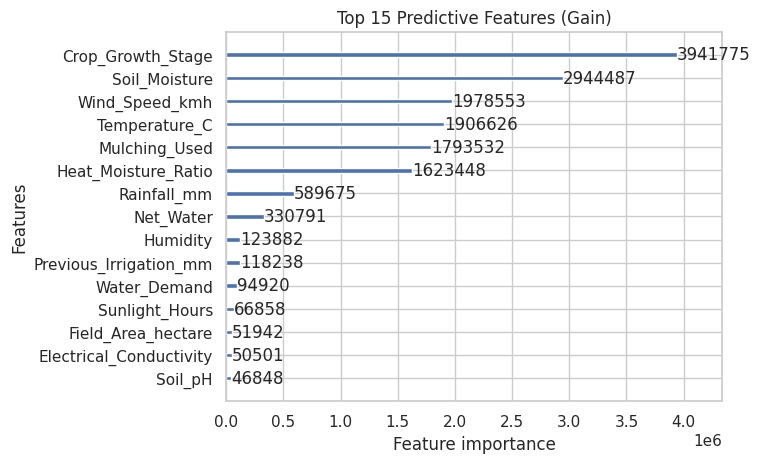


💾 Submission file created successfully. Processing took 16.50 mins.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import warnings
import time

# --- 1. SETTINGS & DATA LOADING ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
start_time = time.time()

print("📂 Loading datasets into Kaggle Environment...")
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")

# --- 2. THE MASTER FEATURE ENGINEERING PIPELINE ---
def engineer_features(df):
    # Interaction: Heat vs Moisture (Primary Signal)
    df['Heat_Moisture_Ratio'] = df['Temperature_C'] / (df['Soil_Moisture'] + 1e-5)
    
    # Atmospheric Water Demand (Evap Index)
    df['Water_Demand'] = (df['Temperature_C'] * df['Sunlight_Hours']) / (df['Humidity'] + 1)
    
    # Net Water Input (Rain + Prev Irrigation)
    df['Net_Water'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    
    # Soil Productivity & Chemical Balance
    df['Soil_Health_Index'] = df['Organic_Carbon'] * df['Electrical_Conductivity']
    df['pH_Deviation'] = abs(df['Soil_pH'] - 7.0) # Distance from neutral pH
    
    # Resource Efficiency
    df['Irrigation_Efficiency'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 1e-5)
    
    # Handling missing values with Median/Mode strategy
    num_cols = df.select_dtypes(include=['float64']).columns
    cat_cols = df.select_dtypes(include=['object']).columns
    
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
        
    return df

print("🛠️ Applying Feature Engineering...")
train = engineer_features(train)
test = engineer_features(test)

# --- 3. ENCODING & PREPARATION ---
target_col = 'Irrigation_Need'
target_le = LabelEncoder()
train[target_col] = target_le.fit_transform(train[target_col])

cat_features = [col for col in train.columns if train[col].dtype == 'object' and col != target_col]
for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

X = train.drop(['id', target_col], axis=1)
y = train[target_col]
X_test = test.drop(['id'], axis=1)

# --- 4. CROSS-VALIDATION ---
lgb_params = {
    'objective': 'multiclass',
    'num_class': 3,
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,    # Slower learning for better precision
    'num_leaves': 128,        
    'max_depth': -1,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'n_jobs': -1,
    'device': 'gpu',          # KAGGLE GPU ENABLED
    'gpu_use_dp': False,      # Using single precision for speed
    'random_state': 42,
    'verbosity': -1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros((len(X), 3))
test_preds = np.zeros((len(X_test), 3))
fold_scores = []

print(f"\n🚀 Training with GPU Acceleration on {len(X)} rows...")
print("-" * 50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Higher n_estimators because of lower learning rate
    model = lgb.LGBMClassifier(**lgb_params, n_estimators=3000)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='multi_logloss',
        callbacks=[
            lgb.early_stopping(stopping_rounds=150),
            lgb.log_evaluation(250)
        ]
    )
    
    fold_probs = model.predict_proba(X_val)
    oof_preds[val_idx] = fold_probs
    test_preds += model.predict_proba(X_test) / skf.n_splits
    
    score = balanced_accuracy_score(y_val, np.argmax(fold_probs, axis=1))
    fold_scores.append(score)
    print(f"✅ Fold {fold+1} | Balanced Accuracy: {score:.5f}")
    print("-" * 50)

# --- 5. FINAL EXPORT ---
mean_score = np.mean(fold_scores)
print(f"\n🏆 FINAL GPU CV SCORE: {mean_score:.5f}")

submission_labels = target_le.inverse_transform(np.argmax(test_preds, axis=1))
submission = pd.DataFrame({'id': test['id'], 'Irrigation_Need': submission_labels})
submission.to_csv('/kaggle/working/submission.csv', index=False)

# Quick Feature Importance Plot
plt.figure(figsize=(10, 6))
lgb.plot_importance(model, max_num_features=15, importance_type='gain', precision=0)
plt.title("Top 15 Predictive Features (Gain)")
plt.show()

print(f"\n💾 Submission file created successfully. Processing took {(time.time()-start_time)/60:.2f} mins.")